In [199]:
import importlib.util
import os
import json
from dotenv import load_dotenv
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from largerNetArchitecture import LargerNet
from standardRegArchitercture import SimpleNet

load_dotenv() 

True

In [200]:
NUM_BINS = 30

working_networks_path = "WorkingNetworks/working_networks_1k_small.pt"
broken_networks_path = "BrokenNetworks/broken_networks.pt"

#Load in the networks
loaded_state_dict = torch.load(working_networks_path)

#create new instantiations to contain the saved networks
num_networks = len(loaded_state_dict)
networks = []
for n in range(num_networks):
    networks.append(SimpleNet())

for i, network in enumerate(networks):
    state_dict_key = f'network_{i+1}'
    network.load_state_dict(loaded_state_dict[state_dict_key])




In [201]:
%matplotlib inline

In [202]:
def getMinOrMax(networks, layerNum, getMin):
    """
    Parameters:
    - networks: an array of trained pytorch networks where the layers are nn.Linear
    - layer: an int representing the fully connected layer to access
    - getMin: a boolean indicating wheter to get the min or max
    Outputs: the minimum or maximum weight in some array of neural networks
    """
    weights = []
    curLayer = -1
    for network in networks:
        for layer in network.children():
            if isinstance(layer, nn.Linear):
                curLayer += 1
                if curLayer == layerNum:
                    #.cpu moves the tensor from the gpu to cpu if it is there in order to use .numpy()
                    weights.extend(layer.weight.data.cpu().numpy().flatten())
        curLayer = -1
    
    if getMin:
        return min(weights) - 1e-6 #small adjustment to account for floating point rounding error, issue occured with getting the upper bound of the max bin
    else:
        return max(weights) + 1e-6

min_weight = getMinOrMax(networks, 0, True)
max_weight = getMinOrMax(networks, 0, False)
min_weight1 = getMinOrMax(networks, 1, True)
max_weight1 = getMinOrMax(networks, 1, False)



In [203]:
layer_weight_distributions = []
layer_bin_ranges = []
network_fc_indices = []
#for each fully connected layer, create matrix of shape (N, M, B) where
#N = num neurons in layer
#M = num neurons in previous layer
#B = number of bins
    
layers = networks[0].children()
#TODO: add layer min and maxes, modify getminmax function
fcLayerNum = -1
for index, layer in enumerate(layers):
    if isinstance(layer, nn.Linear):
        fcLayerNum += 1
        layerMin = getMinOrMax(networks, fcLayerNum, True)
        layerMax = getMinOrMax(networks, fcLayerNum, False)
        #for each layer make an array of shape (num of neurons in layer, num of inputs to layer, num of bins)
        network_fc_indices.append(index)
        layer_shape = layer.weight.shape
        layer_weight_distributions.append(np.zeros(layer_shape + (NUM_BINS,), dtype=int))
        #subtract 1 to make 0-indexed
        bin_edges = np.histogram_bin_edges(a=[], bins=(NUM_BINS), range=(layerMin, layerMax))
        layer_bin_ranges.append(bin_edges)

        
        
#Generate matrix of shape layer, network, neuron, incoming weight
network_weights = []
for index, layer_index in enumerate(network_fc_indices):
    network_weights_per_layer = []
    for network in networks:
        net_layers = list(network.children())
        network_weights_per_layer.append(net_layers[layer_index].weight.data.numpy())
    network_weights.append(network_weights_per_layer)

# print(layer_weight_distributions[0].shape)
print(layer_bin_ranges)
#print the first weight of the first fully connected layer of the first network
print(network_weights)

[array([-1.40404718, -1.31283418, -1.22162118, -1.13040818, -1.03919518,
       -0.94798218, -0.85676918, -0.76555619, -0.67434319, -0.58313019,
       -0.49191719, -0.40070419, -0.30949119, -0.21827819, -0.12706519,
       -0.03585219,  0.05536081,  0.1465738 ,  0.2377868 ,  0.3289998 ,
        0.4202128 ,  0.5114258 ,  0.6026388 ,  0.6938518 ,  0.7850648 ,
        0.8762778 ,  0.96749079,  1.05870379,  1.14991679,  1.24112979,
        1.33234279]), array([-1.5923516 , -1.48343364, -1.37451568, -1.26559773, -1.15667977,
       -1.04776181, -0.93884385, -0.82992589, -0.72100793, -0.61208997,
       -0.50317202, -0.39425406, -0.2853361 , -0.17641814, -0.06750018,
        0.04141778,  0.15033574,  0.25925369,  0.36817165,  0.47708961,
        0.58600757,  0.69492553,  0.80384349,  0.91276145,  1.02167941,
        1.13059736,  1.23951532,  1.34843328,  1.45735124,  1.5662692 ,
        1.67518716]), array([-2.00132017, -1.85687983, -1.71243948, -1.56799914, -1.42355879,
       -1.27911845,

In [204]:

for layer_num, layer_distribution in enumerate(layer_weight_distributions):
    #iterate over neurons in layer
    for i in range(layer_distribution.shape[0]):  
        #iterate over incoming weights to neuron
        for j in range(layer_distribution.shape[1]):  # incoming weights
            # for this weight, iterate over each network to add data to corresponding bin
            for network in network_weights[layer_num]:
                #select network[neuron i, incoming weight j]
                weight = network[i][j]
                corresponding_bin = np.digitize(weight, layer_bin_ranges[layer_num], right=False) - 1
                if corresponding_bin >= NUM_BINS or corresponding_bin < 0:
                    print(weight)
                    print(corresponding_bin)
                
                layer_weight_distributions[layer_num][i][j][corresponding_bin] += 1


#select layer 1, neuron 10, incoming weight 2, and the last bin


In [205]:
print(layer_weight_distributions)


[array([[[  0,   2,   5,  14,  32,  40,  40,  33,  41,  35,  29,  26,
          27,  37,  79, 134,  91,  46,  22,  24,  21,  29,  43,  37,
          41,  33,  24,  11,   4,   0],
        [  0,   0,   2,  10,  20,  53,  61,  45,  32,  34,  34,  46,
          54,  51,  58,  72,  51,  50,  43,  33,  27,  34,  31,  48,
          51,  33,  21,   4,   2,   0]],

       [[  0,   1,   5,  11,  29,  43,  50,  38,  28,  28,  33,  28,
          32,  45,  65, 131,  75,  43,  40,  29,  26,  35,  35,  41,
          45,  34,  16,  14,   0,   0],
        [  1,   2,   5,   8,  24,  42,  68,  50,  38,  33,  33,  67,
          55,  61,  44,  53,  54,  45,  30,  34,  15,  32,  39,  50,
          45,  42,  21,   7,   2,   0]],

       [[  0,   2,   3,  16,  28,  47,  41,  41,  38,  31,  24,  32,
          27,  48,  86, 107,  79,  34,  26,  27,  26,  31,  31,  35,
          63,  43,  23,  10,   1,   0],
        [  2,   2,   6,  18,  23,  43,  61,  47,  37,  41,  39,  63,
          69,  54,  57,  66,  47,  3

[array([-1.40404718, -1.31283418, -1.22162118, -1.13040818, -1.03919518,
       -0.94798218, -0.85676918, -0.76555619, -0.67434319, -0.58313019,
       -0.49191719, -0.40070419, -0.30949119, -0.21827819, -0.12706519,
       -0.03585219,  0.05536081,  0.1465738 ,  0.2377868 ,  0.3289998 ,
        0.4202128 ,  0.5114258 ,  0.6026388 ,  0.6938518 ,  0.7850648 ,
        0.8762778 ,  0.96749079,  1.05870379,  1.14991679,  1.24112979,
        1.33234279]), array([-1.5923516 , -1.48343364, -1.37451568, -1.26559773, -1.15667977,
       -1.04776181, -0.93884385, -0.82992589, -0.72100793, -0.61208997,
       -0.50317202, -0.39425406, -0.2853361 , -0.17641814, -0.06750018,
        0.04141778,  0.15033574,  0.25925369,  0.36817165,  0.47708961,
        0.58600757,  0.69492553,  0.80384349,  0.91276145,  1.02167941,
        1.13059736,  1.23951532,  1.34843328,  1.45735124,  1.5662692 ,
        1.67518716]), array([-2.00132017, -1.85687983, -1.71243948, -1.56799914, -1.42355879,
       -1.27911845,

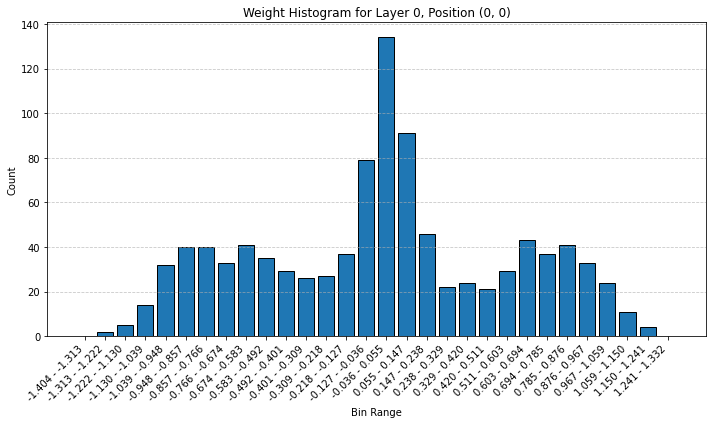

In [206]:
def plot_weight_bins(weight_distributions, layer, weight_position, bin_edges):
    """
    Parameters:
    - weight_distributions: weight counts in the shape (layer, neuron, incoming weight, bin)
    - layer: Index of the layer to plot (0-indexed).
    - weight_position: Tuple indicating the neuron index and incoming weight index in the layer.
    - bin_edges: The edges of the bins for the specified layer, used to label the x-axis with actual values.
    """
    # get the bin data for the specified weight
    weight_distribution = weight_distributions[layer][weight_position[0]][weight_position[1]][:]

    num_bins = len(weight_distribution)

    bin_labels = [f"{bin_edges[i]:.3f} - {bin_edges[i+1]:.3f}" for i in range(num_bins)]
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(num_bins), weight_distribution, width=0.8, align='center', edgecolor='black')
    plt.xlabel('Bin Range')
    plt.ylabel('Count')
    plt.title(f'Weight Histogram for Layer {layer}, Position {weight_position}')
    plt.xticks(range(num_bins), bin_labels, rotation=45, ha='right')  # Rotate for readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()  # Adjust layout to prevent label cut-off
    plt.show()

# neuron 10 in layer 1(0) coming from input neuron 2
print(layer_bin_ranges)
#currently bin_edges are global and aren't specific to each layer
plot_weight_bins(layer_weight_distributions, layer=0, weight_position=(0, 0), bin_edges=layer_bin_ranges[0])


Neuron 0, Incoming Weight 0


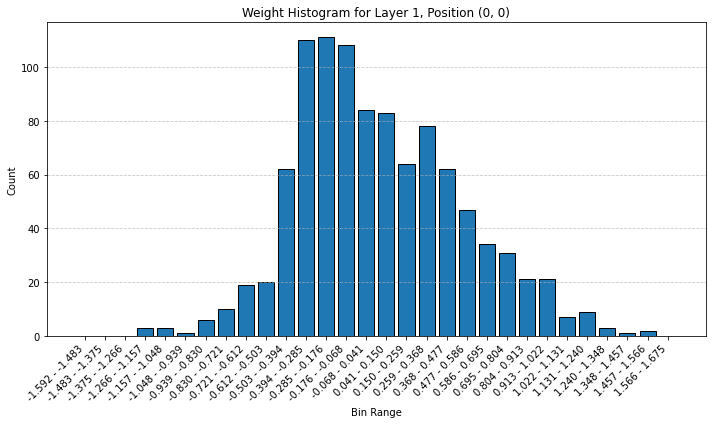

quitting walkthrough.


In [207]:
def weights_walkthrough(weight_distributions, walkthrough_strategy, layer, bin_edges, start_neuron=0):
    """
    Step through the weights of a selected layer using a specified traversal strategy.

    Parameters:
    - weight_distributions: Weight counts in the form (layer, neuron, incoming weight, bin).
    - walkthrough_strategy: 'previous_layer_first' or 'next_layer_first' traversal strategy.
    - layer: Index of the selected layer (0-indexed).
    - bin_edges: The edges of the bins for the selected layer to label the x-axis with actual values.
    - start_neuron: Optional, neuron in the selected layer to start the walkthrough from (default is 0).
    """
    
    num_neurons = weight_distributions[layer].shape[0]  #number of neurons in the selected layer
    num_weights = weight_distributions[layer].shape[1]  #number of weights to each neuron in selected layer

    if walkthrough_strategy == 'previous_layer_first':
        for neuron in range(start_neuron, num_neurons):
            for incoming_weight in range(num_weights):
                print(f"Neuron {neuron}, Incoming Weight {incoming_weight}")
                
                plot_weight_bins(weight_distributions, layer, (neuron, incoming_weight), bin_edges)
                
                user_input = input("Press Enter to continue, or type 'q' to stop: ").strip().lower()
                if user_input == 'q':
                    print("quitting walkthrough.")
                    return
                
    elif walkthrough_strategy == 'next_layer_first':
        for incoming_weight in range(num_weights):
            for neuron in range(start_neuron, num_neurons):
                print(f"Neuron {neuron}, Incoming Weight {incoming_weight}")
                
                plot_weight_bins(weight_distributions, layer, (neuron, incoming_weight), bin_edges)
                
                user_input = input("Press Enter to continue, or type 'q' to stop: ").strip().lower()
                if user_input == 'q':
                    print("quitting walkthrough.")
                    return
                
    else:
        print("Invalid walkthrough strategy. Choose 'previous_layer_first' or 'next_layer_first'.")


weights_walkthrough(layer_weight_distributions, 'previous_layer_first', 1, layer_bin_ranges[1])
# weights_walkthrough(layer_weight_distributions, 'next_layer_first', 0, layer_bin_ranges[0])

In [208]:
normalized_distributions = []
for layer in layer_weight_distributions:
    layer_counts = []
    for neuron in layer:
        neuron_counts = []
        for from_weight in neuron:
            #total should be num of networks
            total = sum(from_weight)
            normalized_bin_counts = [bin_count / total for bin_count in from_weight]
            neuron_counts.append(np.array(normalized_bin_counts))
        layer_counts.append(np.array(neuron_counts))
    normalized_distributions.append(np.array(layer_counts))

print(type(layer_weight_distributions[0]))
print(type(normalized_distributions))

print(normalized_distributions[1][4])
print(layer_weight_distributions[1][4])


<class 'numpy.ndarray'>
<class 'list'>
[[0.    0.    0.    0.    0.001 0.001 0.004 0.009 0.024 0.024 0.099 0.088
  0.093 0.1   0.099 0.083 0.062 0.055 0.047 0.052 0.057 0.03  0.035 0.017
  0.009 0.006 0.002 0.001 0.    0.002]
 [0.    0.    0.    0.    0.    0.004 0.008 0.006 0.007 0.027 0.056 0.102
  0.095 0.1   0.102 0.102 0.077 0.069 0.052 0.047 0.049 0.028 0.027 0.019
  0.01  0.006 0.002 0.004 0.001 0.   ]
 [0.    0.    0.001 0.001 0.001 0.001 0.003 0.011 0.012 0.029 0.068 0.101
  0.114 0.115 0.064 0.073 0.092 0.069 0.064 0.047 0.042 0.027 0.023 0.018
  0.015 0.005 0.002 0.001 0.001 0.   ]
 [0.    0.001 0.    0.002 0.002 0.002 0.005 0.015 0.022 0.025 0.058 0.108
  0.105 0.106 0.094 0.078 0.061 0.083 0.046 0.068 0.047 0.026 0.014 0.014
  0.009 0.002 0.002 0.003 0.002 0.   ]
 [0.    0.    0.003 0.001 0.004 0.003 0.004 0.018 0.016 0.038 0.081 0.108
  0.1   0.102 0.105 0.088 0.069 0.059 0.049 0.044 0.032 0.017 0.024 0.017
  0.011 0.003 0.001 0.002 0.001 0.   ]]
[[  0   0   0   0   1   1

In [209]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def fit_gaussians_to_weight_distributions(weight_distributions, bin_edges_list):
    """
    Fit Gaussian curves to all weight histograms and save the fit parameters.

    Parameters:
    - weight_distributions: List of weight counts, where each element corresponds to a layer and is structured
                            as a NumPy array (neuron, incoming weight, bin).
    - bin_edges_list: List of bin edges for each layer.

    Returns:
    - fit_params: List of fit parameters, mirroring the structure of weight_distributions.
                  Each layer's fit parameters are stored as a NumPy array (neuron, incoming weight, 3).
    """
    fit_params = []

    def gaussian(x, A, mu, sigma):
        return A * np.exp(- (x - mu)**2 / (2 * sigma**2))

    for layer_idx, (layer_data, bin_edges) in enumerate(zip(weight_distributions, bin_edges_list)):
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        num_neurons, num_from_weights, _ = layer_data.shape
        layer_fit_params = np.zeros((num_neurons, num_from_weights, 3))

        for neuron_idx in range(num_neurons):
            for from_weight_idx in range(num_from_weights):
                weight_distribution = layer_data[neuron_idx, from_weight_idx, :]
                #check for existence
                if np.any(weight_distribution):
                    initial_guess = [
                        np.max(weight_distribution),
                        bin_centers[np.argmax(weight_distribution)],
                        np.std(bin_centers)
                    ]
                    try:
                        #fitting
                        popt, _ = curve_fit(gaussian, bin_centers, weight_distribution, p0=initial_guess)
                    except RuntimeError:
                        print(f"Error - curve_fit failed for layer {layer_idx}, neuron {neuron_idx}, from_weight {from_weight_idx}")
                        popt = initial_guess
                else:
                    popt = [0, 0, 0]
                layer_fit_params[neuron_idx, from_weight_idx, :] = popt
        fit_params.append(layer_fit_params)
    return fit_params

def plot_weight_bins_with_fit(weight_distributions, bin_edges, fit_params, layer, weight_position):
    """
    Plot the histogram of weights and the fitted Gaussian curve.

    Parameters:
    - weight_distributions: List of weight counts, where each element corresponds to a layer and is structured
                            as a NumPy array (neuron, incoming weight, bin).
    - bin_edges: Bin edges for the specified layer.
    - fit_params: List of fit parameters, mirroring the structure of weight_distributions.
                  Each layer's fit parameters are stored as a NumPy array (neuron, incoming weight, 3).
    - layer: Index of the layer to plot.
    - weight_position: Tuple indicating the neuron index and incoming weight index in the layer.
    """
    neuron_idx, from_weight_idx = weight_position

    #get data
    weight_distribution = weight_distributions[layer][neuron_idx, from_weight_idx, :]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    #get fit params
    fit_params_layer = fit_params[layer]
    fit_params_for_weight = fit_params_layer[neuron_idx, from_weight_idx, :]

    def gaussian(x, A, mu, sigma):
        return A * np.exp(- (x - mu)**2 / (2 * sigma**2))

    x_fit = np.linspace(bin_edges[0], bin_edges[-1], 1000)
    y_fit = gaussian(x_fit, *fit_params_for_weight)

    plt.figure(figsize=(10, 6))
    plt.bar(bin_centers, weight_distribution, width=np.diff(bin_edges), align='center',
            edgecolor='black', alpha=0.6, label='Histogram')
    plt.plot(x_fit, y_fit, 'r-', label='Fitted Gaussian Curve')
    plt.xlabel('Bin Range')
    plt.ylabel('Count')
    plt.title(f'Weight Histogram and Fitted Curve for Layer {layer}, Position {weight_position}')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


- fit distribution stored as 3 variables in the same 4D matrix as the bin values
- A: amplitude
- mu: mean (center) of Gaussian curve
- sigma: std deviation of curve

[ 0.10480733 -0.07284629  0.40195453]


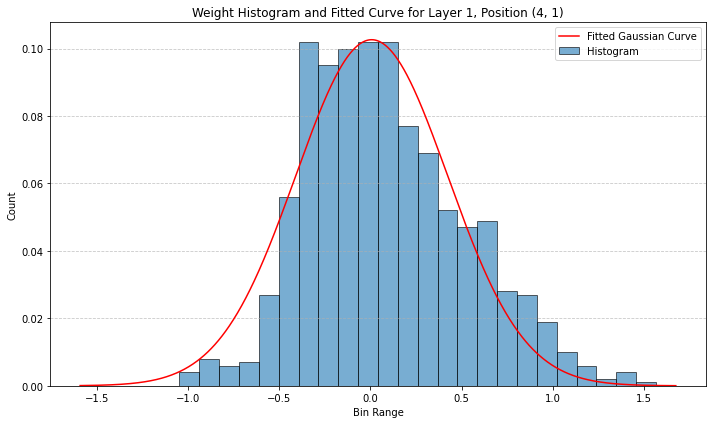

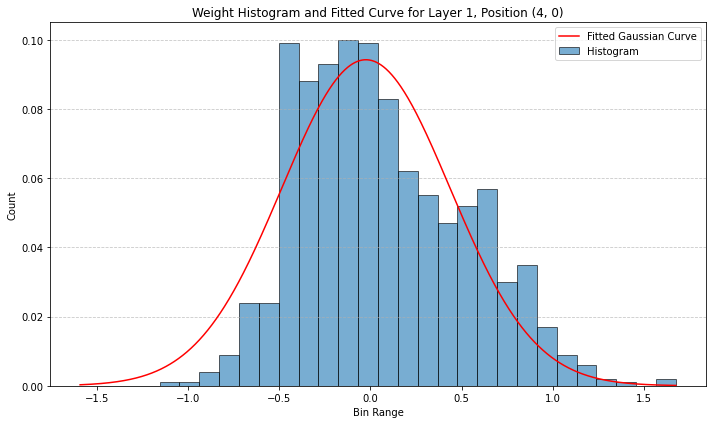

In [210]:
fit_params = fit_gaussians_to_weight_distributions(
    normalized_distributions, bin_edges_list=layer_bin_ranges
)

print(fit_params[1][4][4])

plot_weight_bins_with_fit(
    normalized_distributions, bin_edges=layer_bin_ranges[1],
    fit_params=fit_params, layer=1, weight_position=(4, 1)
)
plot_weight_bins_with_fit(
    normalized_distributions, bin_edges=layer_bin_ranges[1],
    fit_params=fit_params, layer=1, weight_position=(4, 0)
)

In [223]:
def compute_kl_divergence_gaussians(mu1, sigma1, mu2, sigma2):
    sigma1_adj = max(sigma1, 1e-8)
    sigma2_adj = max(sigma2, 1e-8)
    kl_divergence = np.log(sigma2_adj / sigma1_adj) + \
        (sigma1_adj ** 2 + (mu1 - mu2) ** 2) / (2 * sigma2_adj ** 2) - 0.5
    return kl_divergence

def compute_cross_entropy_gaussians(mu1, sigma1, mu2, sigma2):
    sigma2_adj = max(sigma2, 1e-8)
    cross_entropy = 0.5 * np.log(2 * np.pi * sigma2_adj ** 2) + \
        ((sigma1 ** 2 + (mu1 - mu2) ** 2) / (2 * sigma2_adj ** 2))
    return cross_entropy

def cluster_gaussians_by_kl_divergence(fit_params, threshold):
    """
    Cluster Gaussians within each layer based on KL divergence.

    Parameters:
    - fit_params: List of fit parameters for each layer. Each layer is a NumPy array of shape (neurons, from_weights, 3).
    - threshold: KL divergence threshold for clustering.

    Returns:
    - cluster_indices_list: List over layers. Each layer is a NumPy array of shape (neurons, from_weights) containing cluster indices.
    """
    cluster_indices_list = []

    for layer_idx, layer_params in enumerate(fit_params):
        num_neurons, num_from_weights, _ = layer_params.shape
        total_gaussians = num_neurons * num_from_weights

        #flatten params
        mu_sigma_list = []
        for i in range(num_neurons):
            for j in range(num_from_weights):
                A, mu, sigma = layer_params[i, j, :]
                mu_sigma_list.append((mu, sigma))

        #make adjacecny matrix where mat[i, j] is the distance between i and j 
        kl_matrix = np.zeros((total_gaussians, total_gaussians))
        for idx1 in range(total_gaussians):
            mu1, sigma1 = mu_sigma_list[idx1]
            for idx2 in range(idx1 + 1, total_gaussians):
                mu2, sigma2 = mu_sigma_list[idx2]
                kl = compute_kl_divergence_gaussians(mu1, sigma1, mu2, sigma2)
                kl_matrix[idx1, idx2] = kl
                kl_matrix[idx2, idx1] = kl 

        #filter adjacency matrix by the threshold. replaces wit hbools
        adjacency_matrix = kl_matrix < threshold

        #replace with inedexes
        cluster_indices = np.full(total_gaussians, -1, dtype=int)
        current_cluster = 0
        for idx in range(total_gaussians):
            if cluster_indices[idx] == -1:
                cluster_indices[idx] = current_cluster
                queue = [idx]
                while queue:
                    current_idx = queue.pop(0)
                    neighbors = np.where(adjacency_matrix[current_idx])[0]
                    for neighbor_idx in neighbors:
                        if cluster_indices[neighbor_idx] == -1:
                            cluster_indices[neighbor_idx] = current_cluster
                            queue.append(neighbor_idx)
                current_cluster += 1
        #resahpe
        cluster_indices_layer = cluster_indices.reshape((num_neurons, num_from_weights))
        cluster_indices_list.append(cluster_indices_layer)

    return cluster_indices_list

def cluster_gaussians_by_cross_entropy(fit_params, threshold):
    """
    Cluster Gaussians within each layer based on cross-entropy.

    Parameters:
    - fit_params: List of fit parameters for each layer. Each layer is a NumPy array of shape (neurons, from_weights, 3).
    - threshold: Cross-entropy threshold for clustering.

    Returns:
    - cluster_indices_list: List over layers. Each layer is a NumPy array of shape (neurons, from_weights) containing cluster indices.
    """
    cluster_indices_list = []

    for layer_idx, layer_params in enumerate(fit_params):
        num_neurons, num_from_weights, _ = layer_params.shape
        total_gaussians = num_neurons * num_from_weights

        mu_sigma_list = []
        for i in range(num_neurons):
            for j in range(num_from_weights):
                A, mu, sigma = layer_params[i, j, :]
                mu_sigma_list.append((mu, sigma))

        ce_matrix = np.zeros((total_gaussians, total_gaussians))
        for idx1 in range(total_gaussians):
            mu1, sigma1 = mu_sigma_list[idx1]
            for idx2 in range(idx1 + 1, total_gaussians):
                mu2, sigma2 = mu_sigma_list[idx2]
                ce = compute_cross_entropy_gaussians(mu1, sigma1, mu2, sigma2)
                ce_matrix[idx1, idx2] = ce
                ce_matrix[idx2, idx1] = ce

        adjacency_matrix = ce_matrix < threshold

        cluster_indices = np.full(total_gaussians, -1, dtype=int)
        current_cluster = 0
        for idx in range(total_gaussians):
            if cluster_indices[idx] == -1:
                cluster_indices[idx] = current_cluster
                queue = [idx]
                while queue:
                    current_idx = queue.pop(0)
                    neighbors = np.where(adjacency_matrix[current_idx])[0]
                    for neighbor_idx in neighbors:
                        if cluster_indices[neighbor_idx] == -1:
                            cluster_indices[neighbor_idx] = current_cluster
                            queue.append(neighbor_idx)
                current_cluster += 1

        cluster_indices_layer = cluster_indices.reshape((num_neurons, num_from_weights))
        cluster_indices_list.append(cluster_indices_layer)

    return cluster_indices_list


In [224]:
kl_threshold = 0.001
ce_threshold = 0.555

kl_indices = cluster_gaussians_by_kl_divergence(fit_params=fit_params, threshold=kl_threshold)
print(kl_indices)

ce_indices = cluster_gaussians_by_cross_entropy(fit_params=fit_params, threshold=ce_threshold)
print(ce_indices)

[array([[0, 1],
       [0, 2],
       [3, 4],
       [0, 1],
       [5, 1]]), array([[0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0],
       [1, 2, 0, 0, 0],
       [3, 0, 0, 0, 1]]), array([[0, 1, 1, 1, 0]])]
[array([[0, 1],
       [2, 3],
       [4, 5],
       [6, 7],
       [8, 9]]), array([[0, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]]), array([[0, 1, 2, 3, 4]])]


In [225]:
def plot_unique_distributions(indices, layer, normalized_distributions, all_bin_edges, fit_params):
    """
    Plot unique distributions for a specified layer based on cluster indices.

    Parameters:
    - indices: A 3D matrix (list of 2D NumPy arrays) where each element corresponds to a layer,
               and each value in the innermost array represents the cluster index for a Gaussian.
               Shape: (layers, neurons, from_weights).
    - layer: The layer (index) for which to plot unique distributions.
    - normalized_distributions: A 4D matrix representing the normalized weight distributions.
                                Shape: (layers, neurons, from_weights, bins).
    - all_bin_edges: A list of bin edges for each layer, used for plotting the histogram bins.
                     Shape: (layers, bin_edges_per_layer).
    - fit_params: A list of fitted Gaussian parameters for each layer.
                  Shape: (layers, neurons, from_weights, 3).

    Description:
    - This function plots unique Gaussian weight distributions for a specified layer.
    - A distribution is considered "unique" if it belongs to a cluster that has not yet been plotted
      (as determined by the cluster indices in `indices`).
    - The function iterates through the neurons and weights of the specified layer, identifies
      unique distributions (based on their cluster index), and plots them using the provided
      `plot_weight_bins_with_fit` function.
    """
    layer_indices = indices[layer]

    seen_indices = set()

    for i, unique_distribution_neuron_indices in enumerate(layer_indices):
        for j, unique_distribution_index in enumerate(unique_distribution_neuron_indices):
            if unique_distribution_index not in seen_indices:
                plot_weight_bins_with_fit(
                    normalized_distributions, layer_bin_ranges[layer], 
                    fit_params=fit_params, layer=layer, weight_position=(i, j)
                )
                seen_indices.add(unique_distribution_index)


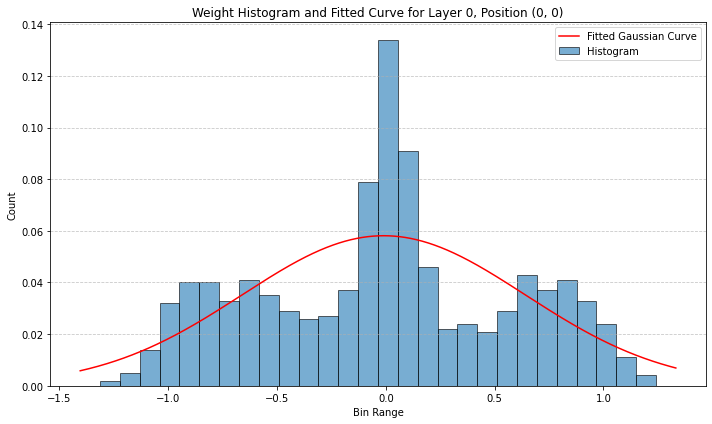

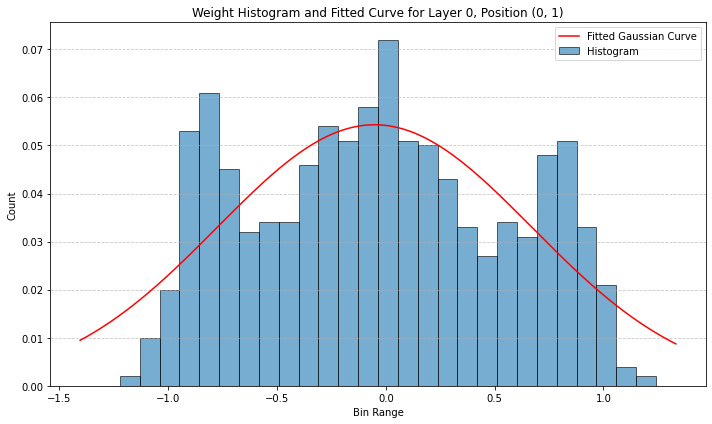

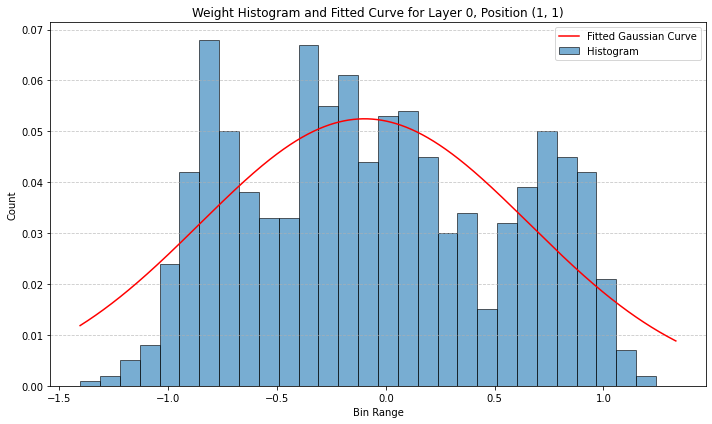

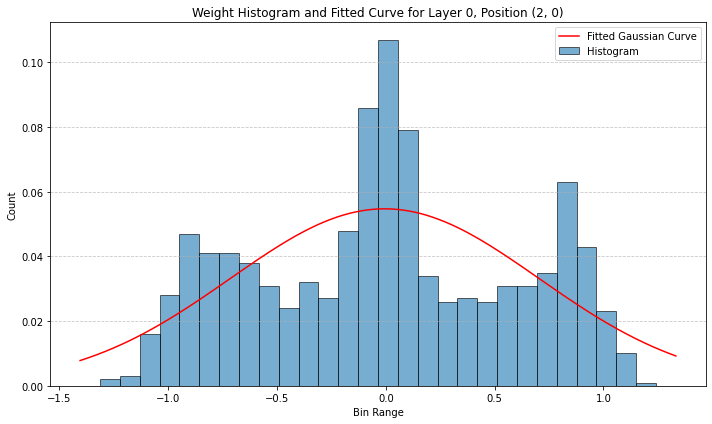

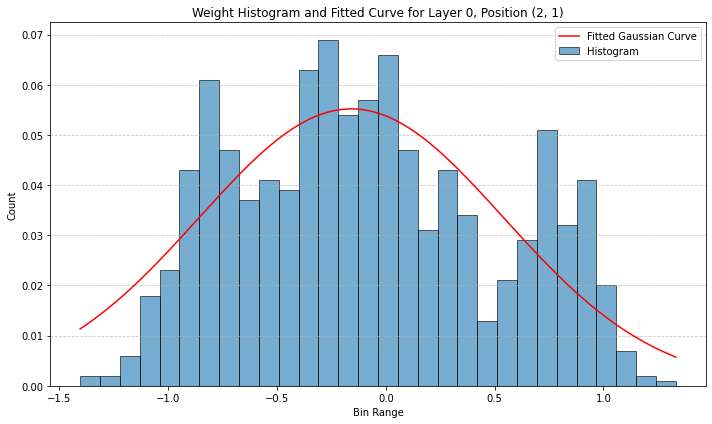

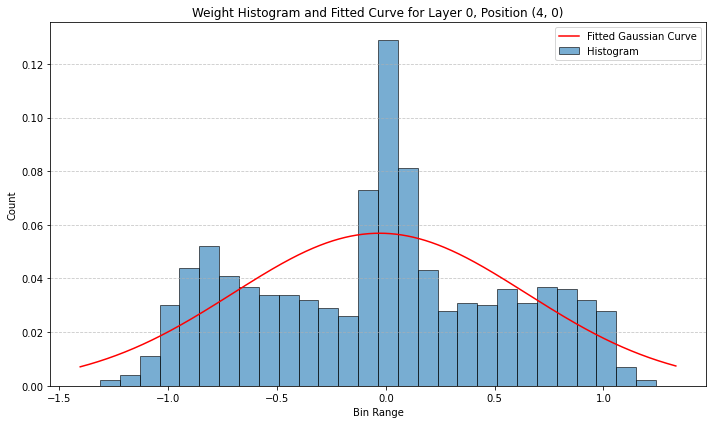

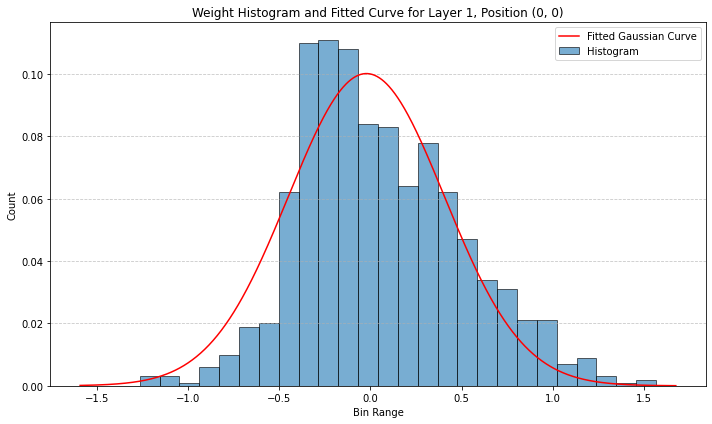

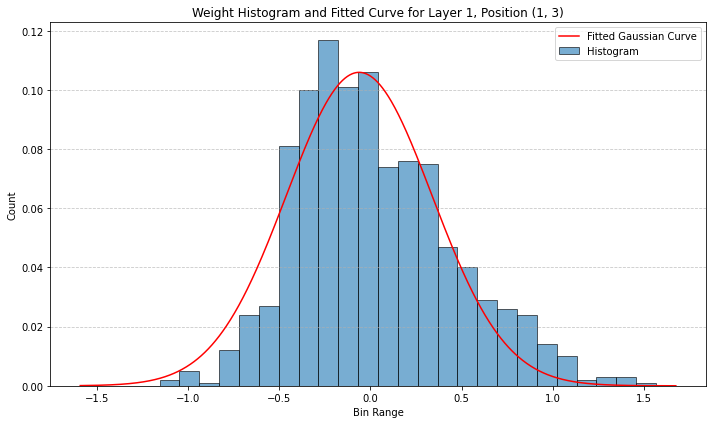

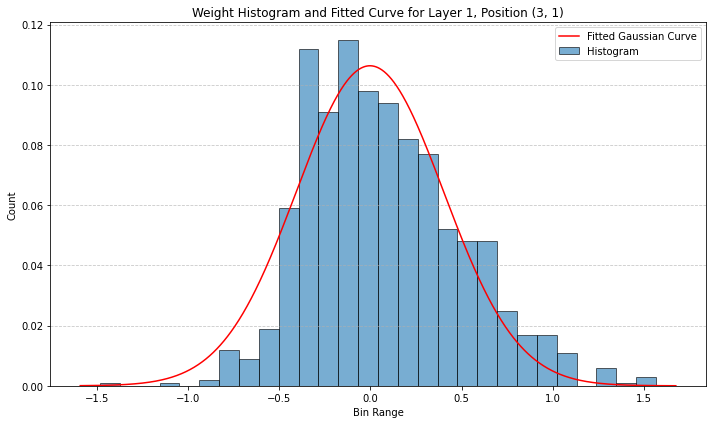

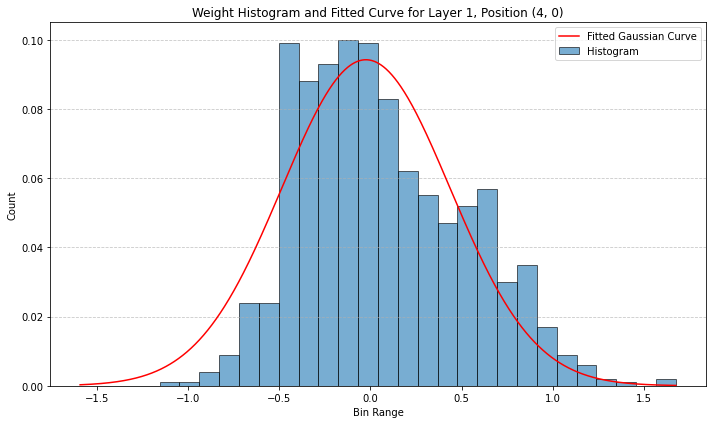

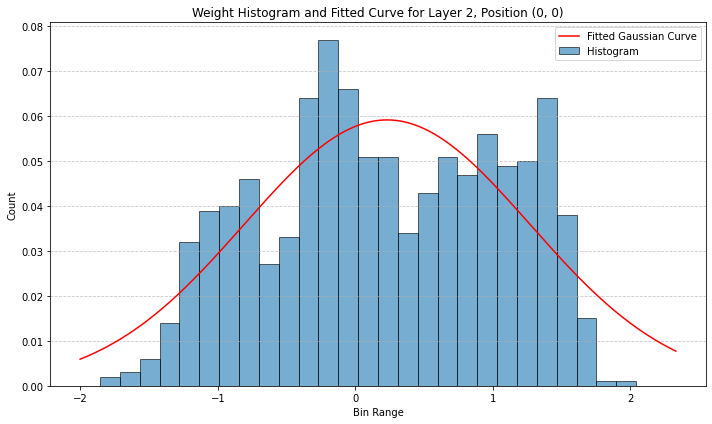

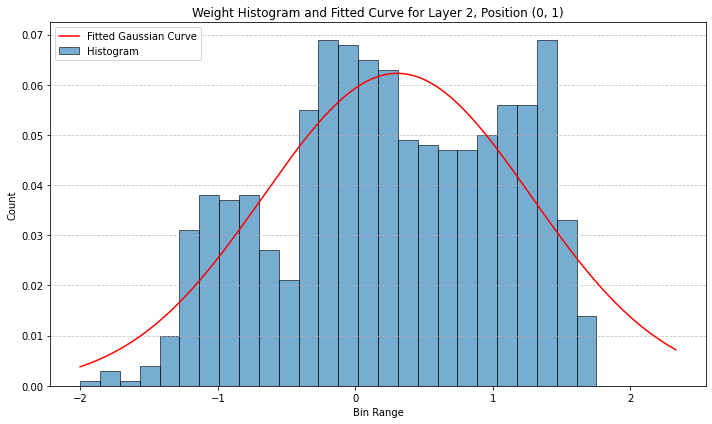

In [226]:
plot_unique_distributions(kl_indices, 0, normalized_distributions, layer_bin_ranges, fit_params)
plot_unique_distributions(kl_indices, 1, normalized_distributions, layer_bin_ranges, fit_params)
plot_unique_distributions(kl_indices, 2, normalized_distributions, layer_bin_ranges, fit_params)
